# P3 - Classification and Unsupervised Analysis: Movie Quality

**Course:** YZM2011 - Introduction to Machine Learning  
**Dataset:** IMDb Top 5000 Movies + TMDB financial data  
**Student ID:** 25018603  
**Chosen Track:** Track A - Classification

This final notebook extends P1 and P2 by classifying whether a movie is highly rated. The target is `good_or_avg`, where `1` means `averageRating >= 7.5` and `0` means `averageRating < 7.5`.
        


# 1. Recap & Task Definition

P1 combined IMDb Top 5000 movie metadata with TMDB production budget and box-office revenue, cleaned title mismatches, imputed missing financial placeholders, and explored relationships among rating, runtime, genre, release year, budget, revenue, profit, and ROI. P2 used the same cleaned data to predict movie `profit` through regression models, but the results showed that exact financial forecasting remains difficult because movie profits are heavily right-skewed and dominated by blockbuster outliers.

For P3, the task is **binary classification**. The target is `good_or_avg`:

- `0`: IMDb average rating is below 7.5, treated as average or below-average within this top-movie sample.
- `1`: IMDb average rating is at least 7.5, treated as highly rated.

This threshold was already introduced in P1, so the classification framing is consistent with the earlier deliverables. The model is framed as a **post-release quality classifier** because vote-count features are included as audience-attention signals. To prevent direct target leakage, `averageRating`, `rating_x_votes`, and IMDb `rank` are excluded from the predictors.
        


In [1]:
from pathlib import Path
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    silhouette_score,
    davies_bouldin_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42
CURRENT_YEAR = 2026

ROOT = Path.cwd()
if not (ROOT / "results_with_crew.csv").exists():
    ROOT = ROOT.parent

print(f"Project root: {ROOT}")
        


Project root: /home/talha/lectures/top_movies_eda


In [2]:
def load_p1_clean_data(root: Path) -> pd.DataFrame:
    """Recreate the cleaned P1 dataset so this notebook runs independently."""
    imdb_data = pd.read_csv(root / "results_with_crew.csv")
    budget_revenue = pd.read_csv(root / "budget_revenue.csv")
    data = imdb_data.copy()
    data[["tmdb_titles", "budget", "revenues"]] = budget_revenue[["tmdb_titles", "budget", "revenue"]]

    writer_corrections = {
        "David Attenborough: A Life on Our Planet": "David Attenborough",
        "Free Solo": "Jimmy Chin, Elizabeth Chai Vasarhelyi",
        "Citizenfour": "Laura Poitras",
        "What Is a Woman?": "Justin Folk",
        "The Act of Killing": "Joshua Oppenheimer, Christine Cynn",
        "They Shall Not Grow Old": "Peter Jackson",
        "Hoop Dreams": "Steve James",
        "Won't You Be My Neighbor?": "Fred Rogers, Kevin Van Sant",
        "Exit Through the Gift Shop": "Banksy, Jaimie D'Cruz",
        "Seaspiracy": "Ali Tabrizi",
        "Apollo 11": "Mark Monroe",
        "Amy": "Asif Kapadia",
        "Jiro Dreams of Sushi": "David Gelb",
        "Black Hawk Down": "Ridley Scott, Robert David Port",
        "Jodorowsky's Dune": "Frank Pavich",
        "The Fog of War": "Errol Morris",
        "Navalny": "Daniel Roher",
        "Jim & Andy: The Great Beyond": "Chris Smith",
        "Capturing the Friedmans": "Alex Gibney",
        "The Imposter": "Andy Grieve",
        "Jesus Camp": "Heidi Ewing, Enat Sidi, Rachel Grady",
        "Miss Americana": "Jenner Furst, Julia Willoughby Nason",
        "Fyre": "Kirby Dick, Amy Ziering",
        "This Is It": "Kenny Ortega, Michael Jackson",
        "American Murder: The Family Next Door": "Rudy Valdez",
        "Catfish": "Henry Joost, Ariel Schulman",
    }
    for title, writer in writer_corrections.items():
        data.loc[data["primaryTitle"] == title, "writers"] = writer

    data.loc[
        data["primaryTitle"] == "Yahsi Bati - The Ottoman Cowboys",
        ["tmdb_titles", "budget", "revenues"],
    ] = ["Yahsi Bati", 2_000_000, 13_565_059]

    diff_fix = pd.read_csv(root / "diff_fix.csv")
    for _, row in diff_fix.iterrows():
        data.loc[
            data["primaryTitle"] == row["imdb_title"],
            ["tmdb_titles", "budget", "revenues"],
        ] = [row["tmdb_title"], row["budget"], row["revenue"]]

    for col in ["budget", "revenues"]:
        zero_mask = data[col].eq(0)
        data.loc[zero_mask, col] = data.loc[~zero_mask, col].median()

    data["profit"] = data["revenues"] - data["budget"]
    data["roi"] = data["profit"] / data["budget"]
    data["good_or_avg"] = (data["averageRating"] >= 7.5).astype(int)

    p60 = data["numVotes"].quantile(0.60)
    p90 = data["numVotes"].quantile(0.90)
    data["popularity"] = 0
    data.loc[(data["numVotes"] >= p60) & (data["numVotes"] < p90), "popularity"] = 1
    data.loc[data["numVotes"] >= p90, "popularity"] = 2
    data["decade"] = (data["startYear"] // 10) * 10

    return data


data = load_p1_clean_data(ROOT)
print("Shape:", data.shape)
print("Missing values:", int(data.isna().sum().sum()))
print("Duplicate rows:", bool(data.duplicated().any()))
display(data[["primaryTitle", "startYear", "genres", "averageRating", "good_or_avg", "budget", "revenues", "profit"]].head())
        


Shape: (5000, 20)
Missing values: 0
Duplicate rows: False


,primaryTitle,startYear,genres,averageRating,good_or_avg,budget,revenues,profit
0,The Shawshank Redemption,1994,Drama,9.3,1,25000000.0,2.834147e+07,3.341469e+06
1,The Godfather,1972,"Crime, Drama",9.2,1,6000000.0,2.450664e+08,2.390664e+08
2,The Dark Knight,2008,"Action, Crime, Drama",9.0,1,185000000.0,1.004558e+09,8.195584e+08
3,The Lord of the Rings: The Return of the King,2003,"Adventure, Drama, Fantasy",9.0,1,94000000.0,1.118889e+09,1.024889e+09
4,Schindler's List,1993,"Biography, Drama, History",9.0,1,22000000.0,3.213656e+08,2.993656e+08


,class,count,share
0,0: rating < 7.5,3448,0.69
1,1: rating >= 7.5,1552,0.31


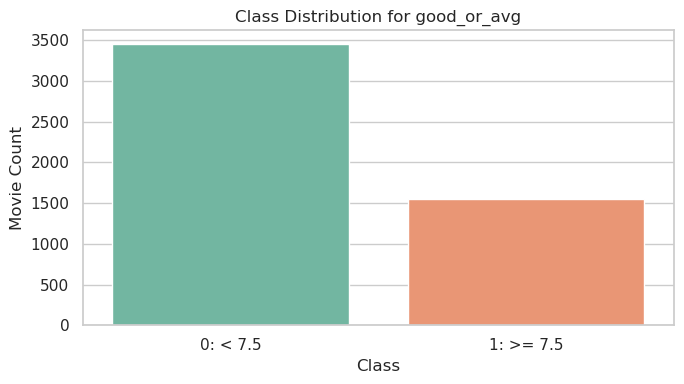

In [3]:
class_counts = data["good_or_avg"].value_counts().sort_index()
class_distribution = pd.DataFrame({
    "class": ["0: rating < 7.5", "1: rating >= 7.5"],
    "count": class_counts.values,
    "share": (class_counts.values / class_counts.sum()).round(3),
})
display(class_distribution)

plt.figure(figsize=(7, 4))
sns.countplot(data=data, x="good_or_avg", hue="good_or_avg", palette="Set2", legend=False)
plt.title("Class Distribution for good_or_avg")
plt.xlabel("Class")
plt.ylabel("Movie Count")
plt.xticks([0, 1], ["0: < 7.5", "1: >= 7.5"])
plt.tight_layout()
plt.show()
        


The target is moderately imbalanced: most movies in the top-5000 sample are below the 7.5 threshold. This is not severe enough to require resampling, but the modeling section uses macro-averaged precision, recall, and F1 so both classes matter. Several model grids also include `class_weight="balanced"` where the estimator supports it.
        


# 2. Data Preparation

The feature engineering starts from P2 and removes leakage-prone variables. P2 used `averageRating` for profit regression, but P3 cannot use it because it directly defines the classification target. The interaction `rating_x_votes` is also removed because it contains `averageRating`, and IMDb `rank` is removed because the list ranking is likely related to rating and vote behavior.

The retained predictors are budget scale, audience attention, runtime, release age, runtime bins, genre indicators, and the budget-vote interaction. The same 60% / 20% / 20% split pattern and `RANDOM_STATE = 42` from P2 are reused so the project remains consistent across deliverables.
        


In [4]:
def add_classification_features(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str], list[str]]:
    model_df = df.copy()

    model_df["log_budget"] = np.log1p(model_df["budget"])
    model_df["log_numVotes"] = np.log1p(model_df["numVotes"])
    model_df["movie_age"] = CURRENT_YEAR - model_df["startYear"]
    model_df["budget_x_votes"] = model_df["log_budget"] * model_df["log_numVotes"]

    runtime_bins = [0, 90, 120, 150, np.inf]
    runtime_labels = ["short", "standard", "long", "epic"]
    model_df["runtime_group"] = pd.cut(
        model_df["runtimeMinutes"],
        bins=runtime_bins,
        labels=runtime_labels,
        include_lowest=True,
    )
    runtime_dummies = pd.get_dummies(model_df["runtime_group"], prefix="runtime_group", dtype=int)
    model_df = pd.concat([model_df, runtime_dummies], axis=1)

    common_genres = [
        "Drama", "Comedy", "Action", "Crime", "Adventure",
        "Thriller", "Romance", "Mystery", "Biography", "Horror", "Sci-Fi",
    ]
    genre_cols = []
    for genre in common_genres:
        col = "genre_" + genre.lower().replace("-", "_")
        model_df[col] = model_df["genres"].str.contains(genre, regex=False).astype(int)
        genre_cols.append(col)

    numeric_features = [
        "budget",
        "log_budget",
        "log_numVotes",
        "runtimeMinutes",
        "movie_age",
        "budget_x_votes",
    ]
    runtime_cols = runtime_dummies.columns.tolist()
    feature_cols = numeric_features + runtime_cols + genre_cols
    return model_df, feature_cols, genre_cols


model_df, base_feature_cols, genre_cols = add_classification_features(data)
print(f"Number of base model features: {len(base_feature_cols)}")
print(base_feature_cols)
display(model_df[base_feature_cols + ["good_or_avg"]].head())
        


Number of base model features: 21
['budget', 'log_budget', 'log_numVotes', 'runtimeMinutes', 'movie_age', 'budget_x_votes', 'runtime_group_short', 'runtime_group_standard', 'runtime_group_long', 'runtime_group_epic', 'genre_drama', 'genre_comedy', 'genre_action', 'genre_crime', 'genre_adventure', 'genre_thriller', 'genre_romance', 'genre_mystery', 'genre_biography', 'genre_horror', 'genre_sci_fi']


,budget,log_budget,log_numVotes,runtimeMinutes,movie_age,budget_x_votes,runtime_group_short,runtime_group_standard,runtime_group_long,runtime_group_epic,...,genre_action,genre_crime,genre_adventure,genre_thriller,genre_romance,genre_mystery,genre_biography,genre_horror,genre_sci_fi,good_or_avg
0,25000000.0,17.034386,14.925773,142,32,254.251391,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1,6000000.0,15.607270,14.566361,175,54,227.341131,0,0,0,1,...,0,1,0,0,0,0,0,0,0,1
2,185000000.0,19.035866,14.918067,152,18,283.978338,0,0,0,1,...,1,1,0,0,0,0,0,0,0,1
3,94000000.0,18.358805,14.544258,201,23,267.015210,0,0,0,1,...,0,0,1,0,0,0,0,0,0,1
4,22000000.0,16.906553,14.233176,195,33,240.633950,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1


In [5]:
feature_notes = pd.DataFrame({
    "feature_group": [
        "Budget scale",
        "Audience attention",
        "Runtime and age",
        "Interactions",
        "Binning",
        "Encoding",
    ],
    "features": [
        "budget, log_budget",
        "log_numVotes",
        "runtimeMinutes, movie_age",
        "budget_x_votes",
        "runtime_group_short/standard/long/epic",
        ", ".join(genre_cols),
    ],
    "why_it_may_help": [
        "Production scale may affect the kind of movie that gets made and promoted.",
        "Vote count is a post-release signal for how much audience attention the movie receives.",
        "Runtime and release era can separate prestige, modern, and older films.",
        "High-budget movies with high audience attention may behave differently from either factor alone.",
        "Runtime effects may be nonlinear, so bins allow short, standard, long, and epic films to differ.",
        "Genres capture category differences that may correlate with rating behavior.",
    ],
})
display(feature_notes)
        


,feature_group,features,why_it_may_help
0,Budget scale,"budget, log_budget",Production scale may affect the kind of movie ...
1,Audience attention,log_numVotes,Vote count is a post-release signal for how mu...
2,Runtime and age,"runtimeMinutes, movie_age","Runtime and release era can separate prestige,..."
3,Interactions,budget_x_votes,High-budget movies with high audience attentio...
4,Binning,runtime_group_short/standard/long/epic,"Runtime effects may be nonlinear, so bins allo..."
5,Encoding,"genre_drama, genre_comedy, genre_action, genre...",Genres capture category differences that may c...


In [6]:
X = model_df[base_feature_cols].copy()
y = model_df["good_or_avg"].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

split_summary = []
for split_name, y_split in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    counts = y_split.value_counts().sort_index()
    split_summary.append({
        "split": split_name,
        "rows": len(y_split),
        "class_0_count": int(counts.get(0, 0)),
        "class_1_count": int(counts.get(1, 0)),
        "class_1_share": float(y_split.mean()),
    })
split_summary = pd.DataFrame(split_summary)
display(split_summary)
        


,split,rows,class_0_count,class_1_count,class_1_share
0,train,3000,2107,893,0.297667
1,validation,1000,671,329,0.329000
2,test,1000,670,330,0.330000


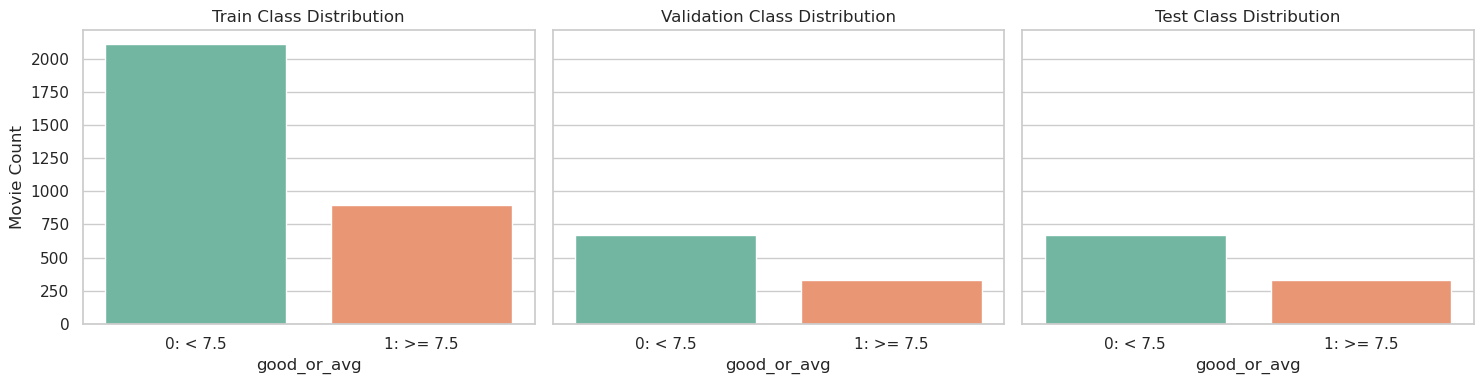

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, split_name, y_split in zip(
    axes,
    ["Train", "Validation", "Test"],
    [y_train, y_val, y_test],
):
    sns.countplot(x=y_split, hue=y_split, palette="Set2", legend=False, ax=ax)
    ax.set_title(f"{split_name} Class Distribution")
    ax.set_xlabel("good_or_avg")
    ax.set_ylabel("Movie Count")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["0: < 7.5", "1: >= 7.5"])
plt.tight_layout()
plt.show()
        


# 3. Unsupervised Analysis

All unsupervised methods below are fit only on the training split after scaling. Validation and test rows are transformed or assigned clusters using objects fitted on the training data only, which prevents data leakage.
        


## 3.1 Dimensionality Reduction with PCA
        


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

pca_full = PCA()
pca_full.fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = int(np.argmax(cumulative_variance >= 0.90) + 1)

pca_summary = pd.DataFrame({
    "component": np.arange(1, len(cumulative_variance) + 1),
    "cumulative_explained_variance": cumulative_variance,
})
print(f"Components needed to explain at least 90% variance: {n_components_90}")
display(pca_summary.head(12))
        


Components needed to explain at least 90% variance: 14


,component,cumulative_explained_variance
0,1,0.177807
1,2,0.293954
2,3,0.378207
3,4,0.454449
4,5,0.517551
5,6,0.578746
6,7,0.631665
7,8,0.683516
8,9,0.729032
9,10,0.770815


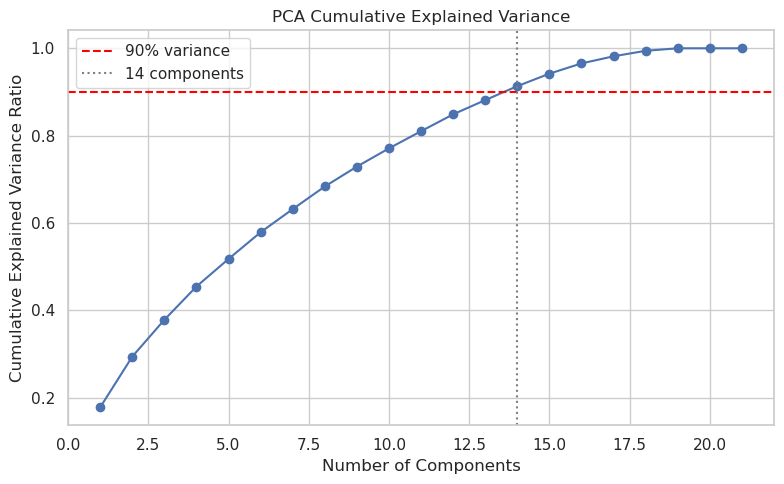

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(pca_summary["component"], pca_summary["cumulative_explained_variance"], marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% variance")
plt.axvline(n_components_90, color="gray", linestyle=":", label=f"{n_components_90} components")
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.legend()
plt.tight_layout()
plt.show()
        


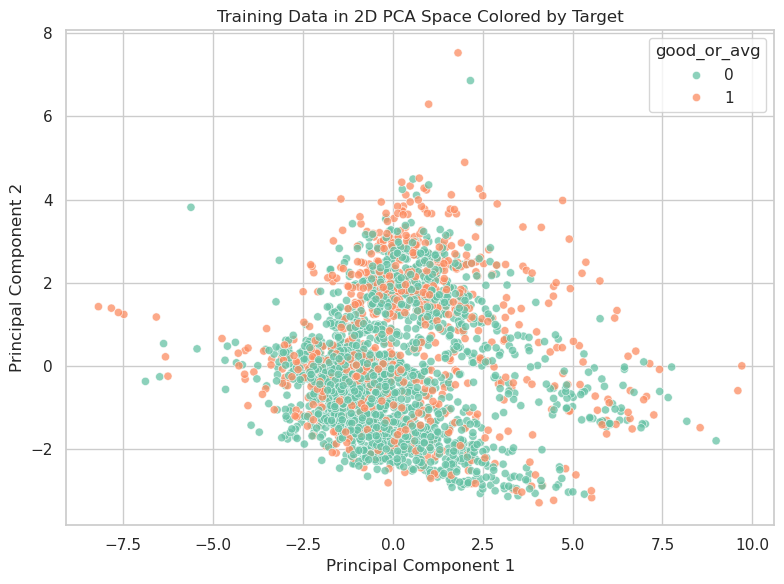

,PC1,PC2
good_or_avg,,
0,-0.084885,-0.246375
1,0.200283,0.581312


In [10]:
pca_2d = PCA(n_components=2)
train_pca_2d = pca_2d.fit_transform(X_train_scaled)
val_pca_2d = pca_2d.transform(X_val_scaled)
test_pca_2d = pca_2d.transform(X_test_scaled)

pca_plot_df = pd.DataFrame({
    "PC1": train_pca_2d[:, 0],
    "PC2": train_pca_2d[:, 1],
    "good_or_avg": y_train.values,
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="good_or_avg",
    palette="Set2",
    alpha=0.75,
    s=35,
)
plt.title("Training Data in 2D PCA Space Colored by Target")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="good_or_avg")
plt.tight_layout()
plt.show()

class_centroids = pca_plot_df.groupby("good_or_avg")[["PC1", "PC2"]].mean()
display(class_centroids)
        


The first two principal components provide a compressed view of the training data, but class overlap is expected because the target is based on rating and the predictors are mostly metadata, financial scale, genre, runtime, and audience attention rather than direct review text. PCA is still useful because it shows whether the engineered feature space contains any broad structure before supervised modeling.
        


## 3.2 Clustering

Two clustering algorithms are tuned:

- **K-Means:** tunes `k` from 2 to 8 using inertia, Silhouette Score, and Davies-Bouldin Index.
- **Gaussian Mixture Model:** tunes `n_components` from 2 to 8 and covariance type using Silhouette Score, Davies-Bouldin Index, BIC, and AIC.

The final choice for each method prioritizes higher Silhouette Score and lower Davies-Bouldin Index because those metrics evaluate compactness and separation without using the class labels.
        


In [11]:
kmeans_rows = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_train_scaled)
    kmeans_rows.append({
        "method": "K-Means",
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X_train_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_train_scaled, labels),
    })

kmeans_results = pd.DataFrame(kmeans_rows)
best_kmeans_row = kmeans_results.sort_values(
    ["silhouette", "davies_bouldin"], ascending=[False, True]
).iloc[0]
best_k = int(best_kmeans_row["k"])

display(kmeans_results)
print(f"Selected K-Means k: {best_k}")
        


,method,k,inertia,silhouette,davies_bouldin
0,K-Means,2,55655.725309,0.147717,2.533919
1,K-Means,3,50674.497455,0.142507,2.217995
2,K-Means,4,46587.902353,0.166068,2.022438
3,K-Means,5,43124.118497,0.173448,1.807010
4,K-Means,6,40727.276324,0.179264,1.765530
5,K-Means,7,38598.537958,0.152628,1.775837
6,K-Means,8,36747.904939,0.167548,1.800858


Selected K-Means k: 6


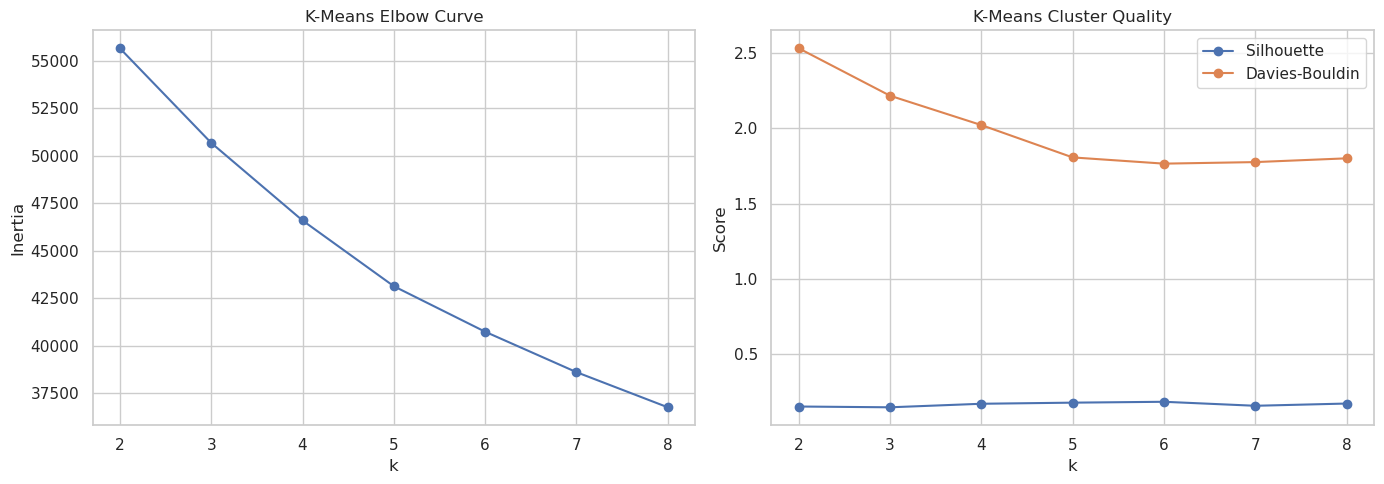

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
axes[0].set_title("K-Means Elbow Curve")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o", label="Silhouette")
axes[1].plot(kmeans_results["k"], kmeans_results["davies_bouldin"], marker="o", label="Davies-Bouldin")
axes[1].set_title("K-Means Cluster Quality")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.tight_layout()
plt.show()
        


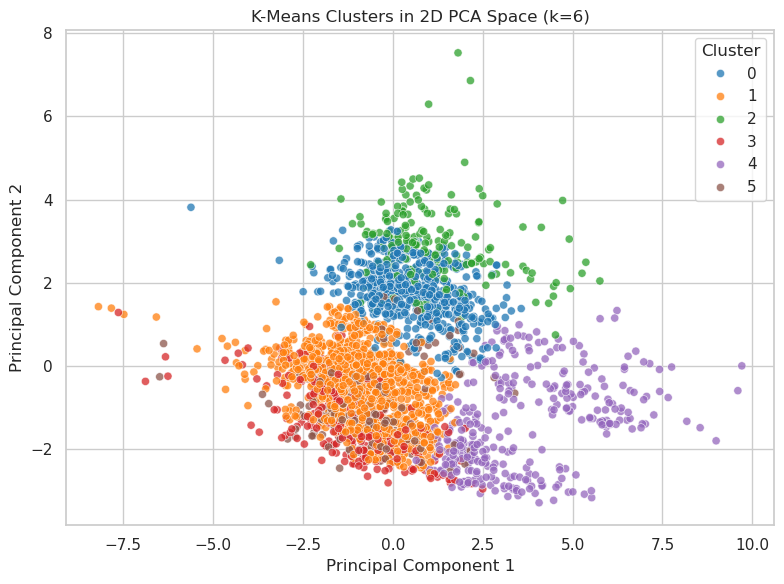

good_or_avg,0,1
cluster,,
0,367,250
1,1035,330
2,71,121
3,199,75
4,245,92
5,190,25


good_or_avg,0,1
cluster,,
0,0.595,0.405
1,0.758,0.242
2,0.370,0.630
3,0.726,0.274
4,0.727,0.273
5,0.884,0.116


In [13]:
best_kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE)
kmeans_train_labels = best_kmeans.fit_predict(X_train_scaled)

kmeans_plot_df = pca_plot_df.copy()
kmeans_plot_df["cluster"] = kmeans_train_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=kmeans_plot_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.75,
    s=35,
)
plt.title(f"K-Means Clusters in 2D PCA Space (k={best_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

kmeans_crosstab_counts = pd.crosstab(kmeans_train_labels, y_train, rownames=["cluster"], colnames=["good_or_avg"])
kmeans_crosstab_share = pd.crosstab(kmeans_train_labels, y_train, normalize="index", rownames=["cluster"], colnames=["good_or_avg"])
display(kmeans_crosstab_counts)
display(kmeans_crosstab_share.round(3))
        


In [14]:
gmm_rows = []
for n_components in range(2, 9):
    for covariance_type in ["full", "diag"]:
        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            reg_covar=1e-6,
            random_state=RANDOM_STATE,
        )
        labels = gmm.fit_predict(X_train_scaled)
        gmm_rows.append({
            "method": "GMM",
            "n_components": n_components,
            "covariance_type": covariance_type,
            "silhouette": silhouette_score(X_train_scaled, labels),
            "davies_bouldin": davies_bouldin_score(X_train_scaled, labels),
            "bic": gmm.bic(X_train_scaled),
            "aic": gmm.aic(X_train_scaled),
        })

gmm_results = pd.DataFrame(gmm_rows)
best_gmm_row = gmm_results.sort_values(
    ["silhouette", "davies_bouldin"], ascending=[False, True]
).iloc[0]
best_gmm_components = int(best_gmm_row["n_components"])
best_gmm_covariance = str(best_gmm_row["covariance_type"])

display(gmm_results.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).head(8))
print(f"Selected GMM: n_components={best_gmm_components}, covariance_type={best_gmm_covariance}")
        


,method,n_components,covariance_type,silhouette,davies_bouldin,bic,aic
10,GMM,7,full,0.173600,1.771627,-83484.365256,-94115.635851
11,GMM,7,diag,0.164187,1.793363,-66647.464945,-68449.375215
12,GMM,8,full,0.157221,1.778146,-104280.053972,-116430.935562
13,GMM,8,diag,0.151788,1.900727,-82505.074398,-84565.258473
0,GMM,2,full,0.147600,2.523430,21223.541208,18190.325586
1,GMM,2,diag,0.147600,2.523430,89076.718619,88566.177376
7,GMM,5,diag,0.103342,2.410364,-45293.644281,-46579.006941
6,GMM,5,full,0.098079,2.586287,-93585.639991,-101177.688597


Selected GMM: n_components=7, covariance_type=full


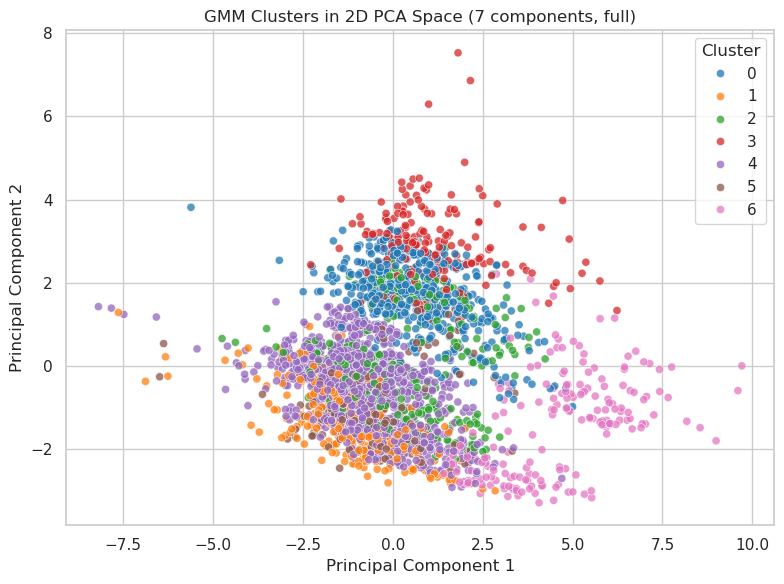

good_or_avg,0,1
cluster,,
0,320,219
1,202,76
2,262,91
3,67,121
4,932,305
5,188,25
6,136,56


good_or_avg,0,1
cluster,,
0,0.594,0.406
1,0.727,0.273
2,0.742,0.258
3,0.356,0.644
4,0.753,0.247
5,0.883,0.117
6,0.708,0.292


In [15]:
best_gmm = GaussianMixture(
    n_components=best_gmm_components,
    covariance_type=best_gmm_covariance,
    reg_covar=1e-6,
    random_state=RANDOM_STATE,
)
gmm_train_labels = best_gmm.fit_predict(X_train_scaled)

gmm_plot_df = pca_plot_df.copy()
gmm_plot_df["cluster"] = gmm_train_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=gmm_plot_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.75,
    s=35,
)
plt.title(f"GMM Clusters in 2D PCA Space ({best_gmm_components} components, {best_gmm_covariance})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

gmm_crosstab_counts = pd.crosstab(gmm_train_labels, y_train, rownames=["cluster"], colnames=["good_or_avg"])
gmm_crosstab_share = pd.crosstab(gmm_train_labels, y_train, normalize="index", rownames=["cluster"], colnames=["good_or_avg"])
display(gmm_crosstab_counts)
display(gmm_crosstab_share.round(3))
        


In [16]:
cluster_comparison = pd.DataFrame([
    {
        "method": "K-Means",
        "params": f"k={best_k}",
        "silhouette": silhouette_score(X_train_scaled, kmeans_train_labels),
        "davies_bouldin": davies_bouldin_score(X_train_scaled, kmeans_train_labels),
    },
    {
        "method": "GMM",
        "params": f"n_components={best_gmm_components}, covariance={best_gmm_covariance}",
        "silhouette": silhouette_score(X_train_scaled, gmm_train_labels),
        "davies_bouldin": davies_bouldin_score(X_train_scaled, gmm_train_labels),
    },
])
cluster_comparison = cluster_comparison.sort_values(
    ["silhouette", "davies_bouldin"], ascending=[False, True]
).reset_index(drop=True)
display(cluster_comparison)

best_cluster_method = cluster_comparison.loc[0, "method"]
print(f"Best clustering run selected for feature engineering: {best_cluster_method}")
        


,method,params,silhouette,davies_bouldin
0,K-Means,k=6,0.179264,1.765530
1,GMM,"n_components=7, covariance=full",0.173600,1.771627


Best clustering run selected for feature engineering: K-Means


The cluster cross-tabs compare unsupervised group assignments against the classification target. Perfect alignment is not expected because clustering does not see the target labels. A useful result is partial alignment, such as a cluster with a noticeably higher share of highly rated movies than the overall training set.
        


## 3.3 Cluster Labels as a Feature

The best clustering run is used to assign one cluster label to every train, validation, and test row. The clusterer is fit only on the training split. A logistic-regression pipeline is then evaluated with and without this feature to quantify whether the cluster label improves validation macro F1.
        


In [17]:
if best_cluster_method == "K-Means":
    best_clusterer = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE)
    train_cluster_labels = best_clusterer.fit_predict(X_train_scaled)
    val_cluster_labels = best_clusterer.predict(X_val_scaled)
    test_cluster_labels = best_clusterer.predict(X_test_scaled)
else:
    best_clusterer = GaussianMixture(
        n_components=best_gmm_components,
        covariance_type=best_gmm_covariance,
        reg_covar=1e-6,
        random_state=RANDOM_STATE,
    )
    train_cluster_labels = best_clusterer.fit_predict(X_train_scaled)
    val_cluster_labels = best_clusterer.predict(X_val_scaled)
    test_cluster_labels = best_clusterer.predict(X_test_scaled)

X_train_clustered = X_train.copy()
X_val_clustered = X_val.copy()
X_test_clustered = X_test.copy()

X_train_clustered["best_cluster"] = train_cluster_labels
X_val_clustered["best_cluster"] = val_cluster_labels
X_test_clustered["best_cluster"] = test_cluster_labels

cluster_feature_cols = X_train_clustered.columns.tolist()
print(f"Feature count with cluster label: {len(cluster_feature_cols)}")
        


Feature count with cluster label: 22


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cluster_compare_grid = {
    "model__C": [0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"],
}

def fit_logistic_for_cluster_check(X_train_eval, X_val_eval, label: str) -> dict:
    search = GridSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2_000, solver="lbfgs", random_state=RANDOM_STATE)),
        ]),
        param_grid=cluster_compare_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
    )
    search.fit(X_train_eval, y_train)
    val_pred = search.predict(X_val_eval)
    return {
        "feature_set": label,
        "best_params": search.best_params_,
        "cv_f1_macro": search.best_score_,
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_f1_macro": f1_score(y_val, val_pred, average="macro"),
    }


cluster_feature_check = pd.DataFrame([
    fit_logistic_for_cluster_check(X_train, X_val, "base features"),
    fit_logistic_for_cluster_check(X_train_clustered, X_val_clustered, "base + best_cluster"),
])
cluster_feature_check["val_f1_delta_vs_base"] = (
    cluster_feature_check["val_f1_macro"] - cluster_feature_check.loc[0, "val_f1_macro"]
)
display(cluster_feature_check)
        


,feature_set,best_params,cv_f1_macro,val_accuracy,val_f1_macro,val_f1_delta_vs_base
0,base features,"{'model__C': 10.0, 'model__class_weight': None}",0.724635,0.767,0.704809,0.0
1,base + best_cluster,"{'model__C': 10.0, 'model__class_weight': None}",0.723182,0.767,0.704809,0.0


# 4. Model Training

The main supervised models use the cluster-enhanced feature matrix so the unsupervised result is included as an engineered feature. Five classifiers are trained and tuned:

- Logistic Regression
- K-Nearest Neighbours
- Decision Tree
- Random Forest
- Gradient Boosting

Random Forest and Gradient Boosting satisfy the ensemble-model requirement. Each model is trained on the training set through `GridSearchCV`, then evaluated on the validation set with accuracy, precision, recall, macro F1, AUC-ROC, and a confusion matrix.
        


# 5. Hyperparameter Tuning

All models use grid search with five-fold stratified cross-validation and macro F1 as the selection score. Macro F1 is used because the positive class is smaller and a high-accuracy model could otherwise perform poorly on highly rated movies. The grids are intentionally compact but cover the key model controls:

- Logistic Regression searches regularization strength `C` and optional class balancing.
- KNN searches neighbor count, distance weighting, and Euclidean vs. Manhattan distance.
- Decision Tree searches depth, minimum leaf size, and optional class balancing.
- Random Forest searches tree count, depth, feature subsampling, leaf size, and optional class balancing.
- Gradient Boosting searches tree count, learning rate, depth, and subsampling.
        


In [19]:
model_specs = {
    "Logistic Regression": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2_000, solver="lbfgs", random_state=RANDOM_STATE)),
        ]),
        "param_grid": {
            "model__C": [0.01, 0.1, 1.0, 10.0],
            "model__class_weight": [None, "balanced"],
        },
    },
    "KNN": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier()),
        ]),
        "param_grid": {
            "model__n_neighbors": [5, 11, 21],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan"],
        },
    },
    "Decision Tree": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ]),
        "param_grid": {
            "model__max_depth": [3, 5, 8, None],
            "model__min_samples_leaf": [5, 20, 50],
            "model__class_weight": [None, "balanced"],
        },
    },
    "Random Forest": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 10, None],
            "model__max_features": ["sqrt", None],
            "model__min_samples_leaf": [1, 5],
            "model__class_weight": [None, "balanced"],
        },
    },
    "Gradient Boosting": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ]),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.1],
            "model__max_depth": [2, 3],
            "model__subsample": [0.8, 1.0],
        },
    },
}

tuned_models = {}
tuning_rows = []

for model_name, spec in model_specs.items():
    print(f"Fitting {model_name}...")
    search = GridSearchCV(
        spec["estimator"],
        param_grid=spec["param_grid"],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        return_train_score=True,
    )
    search.fit(X_train_clustered, y_train)
    tuned_models[model_name] = search
    tuning_rows.append({
        "Model": model_name,
        "Best CV F1 (macro)": search.best_score_,
        "Best Hyperparameters": search.best_params_,
    })

tuning_results = pd.DataFrame(tuning_rows)
display(tuning_results)
        


Fitting Logistic Regression...
Fitting KNN...
Fitting Decision Tree...
Fitting Random Forest...
Fitting Gradient Boosting...


,Model,Best CV F1 (macro),Best Hyperparameters
0,Logistic Regression,0.723182,"{'model__C': 10.0, 'model__class_weight': None}"
1,KNN,0.682639,"{'model__metric': 'euclidean', 'model__n_neigh..."
2,Decision Tree,0.713302,"{'model__class_weight': 'balanced', 'model__ma..."
3,Random Forest,0.747990,"{'model__class_weight': 'balanced', 'model__ma..."
4,Gradient Boosting,0.748322,"{'model__learning_rate': 0.1, 'model__max_dept..."


In [20]:
def evaluate_classifier(name: str, estimator, X_eval, y_eval, split_name: str) -> dict:
    pred = estimator.predict(X_eval)
    prob = estimator.predict_proba(X_eval)[:, 1]
    return {
        "Model": name,
        f"{split_name} Accuracy": accuracy_score(y_eval, pred),
        f"{split_name} Precision (macro)": precision_score(y_eval, pred, average="macro", zero_division=0),
        f"{split_name} Recall (macro)": recall_score(y_eval, pred, average="macro", zero_division=0),
        f"{split_name} F1 (macro)": f1_score(y_eval, pred, average="macro"),
        f"{split_name} AUC-ROC": roc_auc_score(y_eval, prob),
    }


validation_rows = []
for model_name, search in tuned_models.items():
    validation_rows.append(evaluate_classifier(
        model_name,
        search.best_estimator_,
        X_val_clustered,
        y_val,
        "Val",
    ))

validation_results = pd.DataFrame(validation_rows).sort_values(
    ["Val F1 (macro)", "Val Accuracy"], ascending=[False, False]
)
display(validation_results)
        


,Model,Val Accuracy,Val Precision (macro),Val Recall (macro),Val F1 (macro),Val AUC-ROC
3,Random Forest,0.785,0.756602,0.754585,0.755568,0.851616
4,Gradient Boosting,0.775,0.761131,0.702982,0.717549,0.833271
0,Logistic Regression,0.767,0.752167,0.690823,0.704809,0.784439
2,Decision Tree,0.725,0.690634,0.695933,0.692968,0.800395
1,KNN,0.728,0.693649,0.647045,0.655799,0.745947


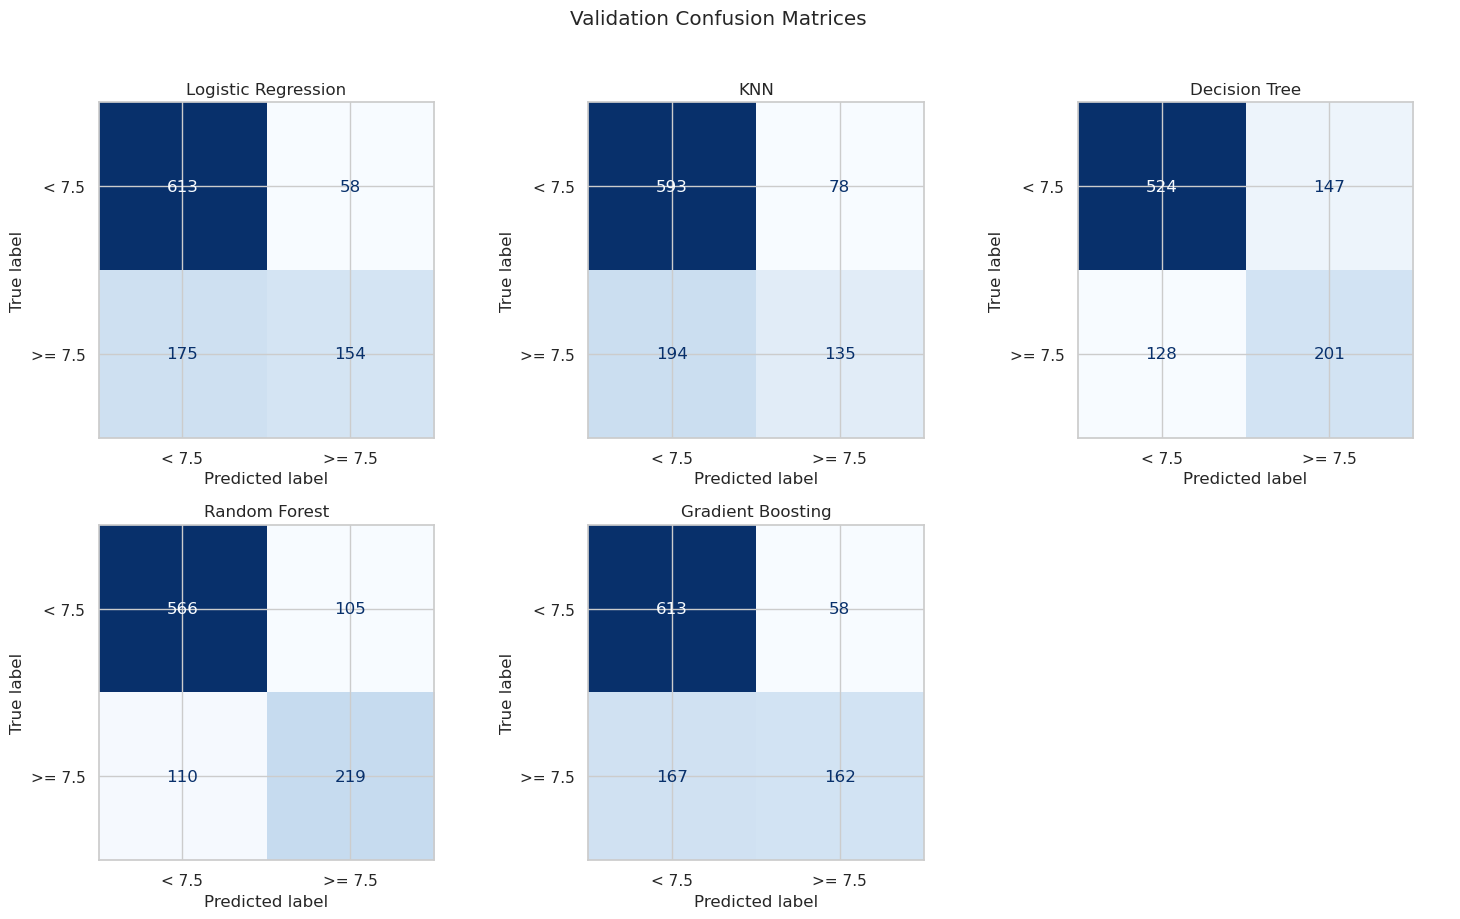

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, (model_name, search) in zip(axes, tuned_models.items()):
    val_pred = search.best_estimator_.predict(X_val_clustered)
    ConfusionMatrixDisplay.from_predictions(
        y_val,
        val_pred,
        display_labels=["< 7.5", ">= 7.5"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(model_name)

for ax in axes[len(tuned_models):]:
    ax.axis("off")

plt.suptitle("Validation Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()
        


# 6. Model Comparison

The table below combines validation and test metrics for each tuned model. The best model is selected by validation macro F1, with validation accuracy used as a tie-breaker. The test set is used only after model selection to estimate final generalization performance.
        


In [22]:
comparison_rows = []
for model_name, search in tuned_models.items():
    row = evaluate_classifier(model_name, search.best_estimator_, X_val_clustered, y_val, "Val")
    row.update(evaluate_classifier(model_name, search.best_estimator_, X_test_clustered, y_test, "Test"))
    comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows)
comparison = comparison.sort_values(["Val F1 (macro)", "Val Accuracy"], ascending=[False, False]).reset_index(drop=True)
comparison["Selected"] = ""
comparison.loc[0, "Selected"] = "Best tuned model"

metric_cols = [
    "Val Accuracy",
    "Val F1 (macro)",
    "Test Accuracy",
    "Test F1 (macro)",
    "Test AUC-ROC",
]
display_cols = ["Model", "Selected"] + metric_cols
display(comparison[display_cols])

best_model_name = comparison.loc[0, "Model"]
best_estimator = tuned_models[best_model_name].best_estimator_
print(f"Selected best model: {best_model_name}")
        


,Model,Selected,Val Accuracy,Val F1 (macro),Test Accuracy,Test F1 (macro),Test AUC-ROC
0,Random Forest,Best tuned model,0.785,0.755568,0.796,0.766773,0.844790
1,Gradient Boosting,,0.775,0.717549,0.788,0.736527,0.844928
2,Logistic Regression,,0.767,0.704809,0.783,0.726972,0.808087
3,Decision Tree,,0.725,0.692968,0.731,0.703009,0.796298
4,KNN,,0.728,0.655799,0.735,0.661087,0.750970


Selected best model: Random Forest


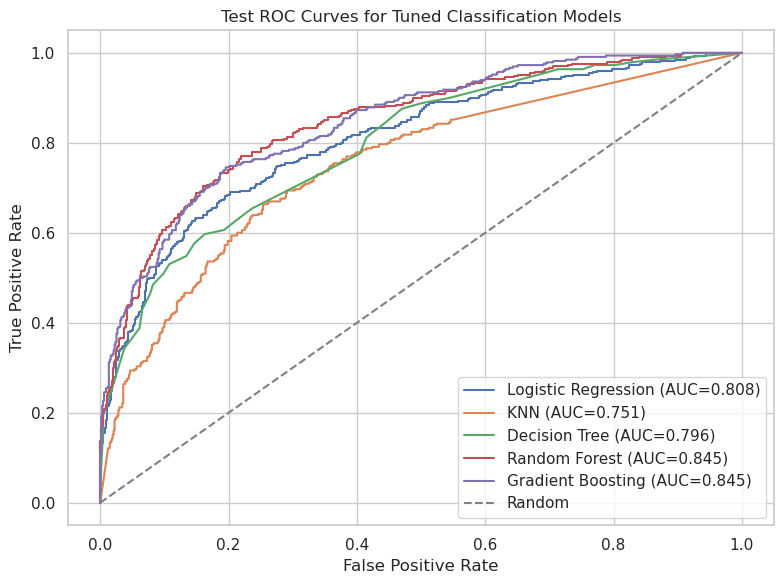

In [23]:
plt.figure(figsize=(8, 6))
for model_name, search in tuned_models.items():
    test_prob = search.best_estimator_.predict_proba(X_test_clustered)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, test_prob)
    auc_value = roc_auc_score(y_test, test_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
plt.title("Test ROC Curves for Tuned Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()
        


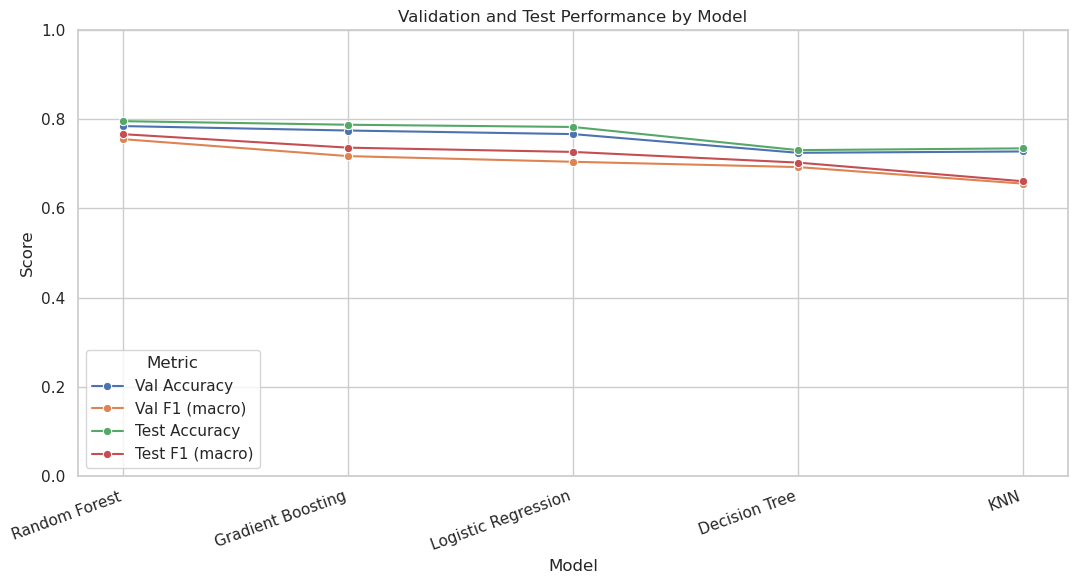

In [24]:
metric_plot = comparison.melt(
    id_vars="Model",
    value_vars=["Val Accuracy", "Val F1 (macro)", "Test Accuracy", "Test F1 (macro)"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(11, 6))
sns.lineplot(data=metric_plot, x="Model", y="Score", hue="Metric", marker="o")
plt.title("Validation and Test Performance by Model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()
        


# 7. Error Analysis

The selected model is examined on the held-out test set. Misclassified examples are sorted by model confidence to identify the strongest mistakes, then false positives and false negatives are counted separately. Feature importance is reported from the selected estimator when available; otherwise permutation importance is used.
        


In [25]:
test_pred = best_estimator.predict(X_test_clustered)
test_prob = best_estimator.predict_proba(X_test_clustered)[:, 1]

test_errors = model_df.loc[X_test.index, [
    "primaryTitle",
    "startYear",
    "genres",
    "averageRating",
    "numVotes",
    "budget",
    "revenues",
    "profit",
]].copy()
test_errors["actual"] = y_test.values
test_errors["predicted"] = test_pred
test_errors["probability_highly_rated"] = test_prob
test_errors["confidence"] = np.where(test_pred == 1, test_prob, 1 - test_prob)
test_errors["error_type"] = np.select(
    [
        (test_errors["actual"] == 0) & (test_errors["predicted"] == 1),
        (test_errors["actual"] == 1) & (test_errors["predicted"] == 0),
    ],
    ["false_positive", "false_negative"],
    default="correct",
)

misclassified = test_errors[test_errors["actual"] != test_errors["predicted"]].copy()
print(f"Total test misclassifications: {len(misclassified)} out of {len(test_errors)}")
display(misclassified.sort_values("confidence", ascending=False).head(12))

error_type_counts = test_errors["error_type"].value_counts().rename_axis("error_type").reset_index(name="count")
display(error_type_counts)
        


Total test misclassifications: 204 out of 1000


,primaryTitle,startYear,genres,averageRating,numVotes,budget,revenues,profit,actual,predicted,probability_highly_rated,confidence,error_type
1172,Guillermo del Toro's Pinocchio,2022,"Adventure, Animation, Drama",7.6,120191,35000000.0,39000000.0,4000000.0,1,0,0.069692,0.930308,false_negative
1225,The Killer,1989,"Action, Crime, Drama",7.7,52933,30000000.0,318618.0,-29681382.0,1,0,0.070955,0.929045,false_negative
1578,Mesrine: Killer Instinct,2008,"Action, Biography, Crime",7.5,35957,25000000.0,15000000.0,-10000000.0,1,0,0.080101,0.919899,false_negative
996,Ninja Scroll,1993,"Action, Adventure, Animation",7.8,42791,60000000.0,1070.0,-59998930.0,1,0,0.099408,0.900592,false_negative
1180,The Secret World of Arrietty,2010,"Adventure, Animation, Drama",7.6,110786,23000000.0,149660003.0,126660003.0,1,0,0.105129,0.894871,false_negative
1630,Les Misérables,2019,"Crime, Drama, Thriller",7.6,29467,14000000.0,14096321.0,96321.0,1,0,0.115015,0.884985,false_negative
1158,Star Trek: First Contact,1996,"Action, Adventure, Drama",7.6,134872,46000000.0,146027888.0,100027888.0,1,0,0.117374,0.882626,false_negative
1110,Stranger Than Fiction,2006,"Comedy, Drama, Fantasy",7.5,240644,30000000.0,53653224.0,23653224.0,1,0,0.123511,0.876489,false_negative
2704,Mohabbatein,2000,"Drama, Musical, Romance",7.0,35078,4000000.0,20000000.0,16000000.0,0,1,0.872786,0.872786,false_positive
654,Isle of Dogs,2018,"Adventure, Animation, Comedy",7.8,199424,62770198.0,64337744.0,1567546.0,1,0,0.146707,0.853293,false_negative


,error_type,count
0,correct,796
1,false_negative,109
2,false_positive,95


In [26]:
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

confusion_summary = pd.DataFrame({
    "confusion_type": ["true_negative", "false_positive", "false_negative", "true_positive"],
    "count": [tn, fp, fn, tp],
})
display(confusion_summary)

if fp > fn:
    print("The selected model is more confused by average movies that it predicts as highly rated.")
elif fn > fp:
    print("The selected model is more confused by highly rated movies that it predicts as average.")
else:
    print("The selected model has equal false-positive and false-negative counts.")
        


,confusion_type,count
0,true_negative,575
1,false_positive,95
2,false_negative,109
3,true_positive,221


The selected model is more confused by highly rated movies that it predicts as average.


,feature,importance
2,log_numVotes,0.201372
4,movie_age,0.187355
5,budget_x_votes,0.114368
3,runtimeMinutes,0.104563
1,log_budget,0.088302
0,budget,0.087560
21,best_cluster,0.033234
7,runtime_group_standard,0.030373
10,genre_drama,0.023068
11,genre_comedy,0.022804


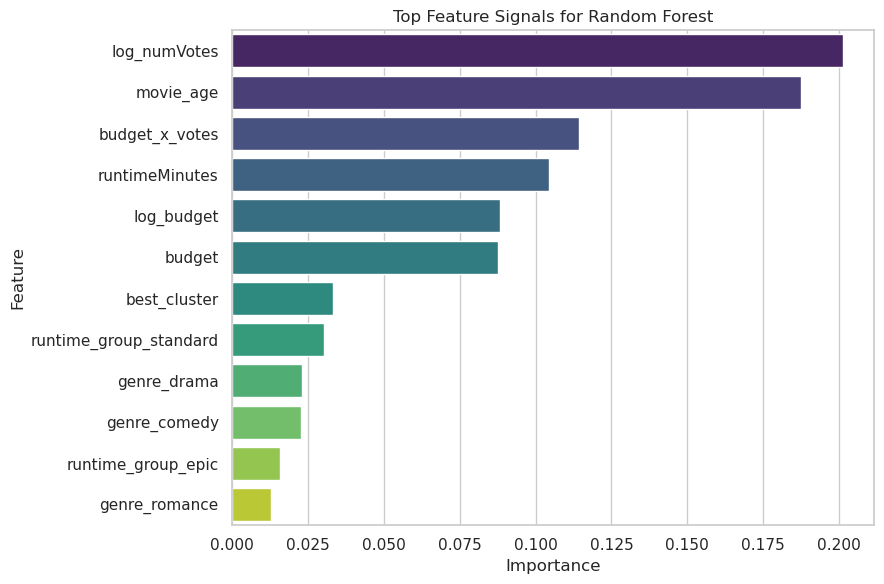

In [27]:
final_feature_names = X_train_clustered.columns.tolist()
selected_model = best_estimator.named_steps["model"]

if hasattr(selected_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": final_feature_names,
        "importance": selected_model.feature_importances_,
    }).sort_values("importance", ascending=False)
elif hasattr(selected_model, "coef_"):
    importance_df = pd.DataFrame({
        "feature": final_feature_names,
        "importance": np.abs(selected_model.coef_[0]),
    }).sort_values("importance", ascending=False)
else:
    perm = permutation_importance(
        best_estimator,
        X_test_clustered,
        y_test,
        scoring="f1_macro",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importance_df = pd.DataFrame({
        "feature": final_feature_names,
        "importance": perm.importances_mean,
    }).sort_values("importance", ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df.head(12), x="importance", y="feature", hue="feature", palette="viridis", legend=False)
plt.title(f"Top Feature Signals for {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
        


# 8. Final Written Report

## Introduction

This project studies the IMDb Top 5000 movie dataset enriched with TMDB financial information. The broader question is what factors help explain movie success, both commercially and in terms of audience reception. P1 focused on data cleaning and exploratory analysis, P2 built regression models to predict movie profit, and P3 reframes the final task as classification: predicting whether a movie is highly rated. The P3 target is `good_or_avg`, where movies with `averageRating >= 7.5` are labeled as highly rated and all others are labeled as average or below-average within this already selective top-5000 sample.

## Methods

P1 merged IMDb metadata with TMDB budget and revenue fields, corrected title mismatches, handled missing financial placeholders, and engineered `profit`, `roi`, `good_or_avg`, `popularity`, and decade features. P2 reused this cleaned table for regression, adding log transforms, runtime bins, genre indicators, movie age, and interaction features. P3 keeps the same data reconstruction approach and the same 60/20/20 train, validation, and test split pattern with `RANDOM_STATE = 42`. Because the target is based on IMDb rating, direct leakage features are removed: `averageRating`, `rating_x_votes`, and IMDb `rank` are not used as predictors. The remaining features describe budget scale, vote attention, runtime, age, genre, and a budget-vote interaction.

Before supervised learning, P3 applies unsupervised analysis on the scaled training data only. PCA is used to inspect variance structure and visualize the first two principal components. K-Means and Gaussian Mixture clustering are tuned using Silhouette Score and Davies-Bouldin Index, then the best cluster assignment is added as an engineered feature. Five classifiers are tuned with five-fold stratified GridSearchCV: Logistic Regression, KNN, Decision Tree, Random Forest, and Gradient Boosting. Macro F1 is the main validation criterion because the highly rated class is smaller than the below-threshold class.

## Results

P1 found that financial variables are highly right-skewed and that budget has the strongest linear relationship with profit. It also showed that rating is only weakly related to budget and revenue, while runtime and release year have more noticeable relationships with rating. P2 confirmed that profit prediction is possible at a broad trend level but difficult at exact dollar scale. The best P2 model was degree-2 polynomial regression, with final test performance around R^2 = 0.52, RMSE = $109M, and MAE = $58M.

In P3, the class distribution is moderately imbalanced: 3,448 movies are below 7.5 and 1,552 are at least 7.5. The reused split produced class-1 shares of about 29.8% in training and 33.0% in validation and test. PCA required 14 components to explain at least 90% of the scaled training variance, and the 2D projection showed substantial overlap between the two classes. K-Means with k=6 was selected over the best GMM run because it had a slightly higher Silhouette Score, 0.179 versus 0.174, and a slightly lower Davies-Bouldin Index, 1.766 versus 1.772. The cluster labels only partially aligned with the target: for example, one K-Means cluster had about 63% highly rated movies, while another had only about 12%.

The tuned Random Forest was selected as the best model. It achieved validation accuracy of 0.785, validation macro F1 of 0.756, and validation AUC-ROC of 0.852. On the held-out test set, it achieved accuracy of 0.796, macro F1 of 0.767, and AUC-ROC of 0.845. Error analysis found 204 test misclassifications: 95 false positives and 109 false negatives, so the model was slightly more likely to miss highly rated movies than to over-label average movies as highly rated. The strongest feature signals were `log_numVotes`, `movie_age`, `budget_x_votes`, `runtimeMinutes`, `log_budget`, and `budget`, with the cluster label contributing a smaller but visible signal.

## Discussion

The main strength of the final pipeline is that it is complete and leakage-aware. It rebuilds the cleaned dataset, preserves the P2 split strategy, fits preprocessing only on training data, includes unsupervised structure discovery, tunes every classifier through cross-validation, and evaluates the chosen model on a held-out test set. The results also make practical sense: audience attention, release era, runtime, and production scale help distinguish highly rated films, but they do not perfectly explain taste or quality. The main limitation is that movie quality is hard to infer from metadata alone. Important signals such as screenplay quality, acting, cultural context, critic reviews, marketing, franchise status, and release competition are absent. Vote count is useful, but it also means this model is post-release rather than a true pre-release predictor.

## Conclusion

Across the three deliverables, the project moved from data understanding to regression and then to classification. P1 showed the dataset's structure and limitations, P2 showed that exact profit prediction is noisy because of extreme outliers, and P3 provides a more stable final task by classifying highly rated movies. The practical value of the model is not that it can perfectly judge film quality, but that it demonstrates how budget, attention, runtime, age, genre, and unsupervised group structure can be combined into a reproducible machine-learning pipeline.
